In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.colors as mcolors

import pandas as pd
import xarray as xr
import os

import matplotlib.dates as mdates

from scipy.spatial import cKDTree

In [33]:
ds_0 = xr.open_dataset("C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Maps_diff//hs_mean_diff01.nc", engine="h5netcdf")
ds_0

<xarray.Dataset> Size: 16MB
Dimensions:    (time: 1, bnds: 2, latitude: 787, longitude: 1651)
Coordinates:
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
  * time       (time) datetime64[ns] 8B 2020-01-16T11:30:00
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 16B ...
    diff       (time, latitude, longitude) float32 5MB ...
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    product_name:                     ww3.run_with_currents202001.nc
    ...                               ...
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...
    history:                          Thu Oct  9 13:26:05 2025: ncks -A lan_l...
    history_of_appended_files:        Thu Oct  9 13:26:05 2025: Appended file...
    NCO:                              "4.5.2"

In [34]:
csv_file = "C://Users//kosta//OneDrive//Desktop//Διπλωματική//Data//byos.csv"

# 1. Read the CSV into a pandas DataFrame
df_altim = pd.read_csv(csv_file)
print("Pandas DataFrame:")
print(df_altim)

Pandas DataFrame:
       variable           platform_id platform_type                  time  \
0          VAVH               1801573            SD  2020-03-05T22:30:00Z   
1          VAVH               1801573            SD  2020-03-05T23:00:00Z   
2          VAVH               1801573            SD  2020-03-05T23:30:00Z   
3          VAVH               1801573            SD  2020-03-06T00:00:00Z   
4          VAVH               1801573            SD  2020-03-06T00:30:00Z   
...         ...                   ...           ...                   ...   
546185     VHM0  Tarragona-coast-buoy            MO  2020-12-31T20:00:00Z   
546186     VHM0  Tarragona-coast-buoy            MO  2020-12-31T21:00:00Z   
546187     VHM0  Tarragona-coast-buoy            MO  2020-12-31T22:00:00Z   
546188     VHM0  Tarragona-coast-buoy            MO  2020-12-31T23:00:00Z   
546189     VHM0  Tarragona-coast-buoy            MO  2021-01-01T00:00:00Z   

        longitude  latitude  depth  pressure  is_depth_fr

C:\Users\kosta\AppData\Local\Temp\ipykernel_9636\155476583.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_altim = pd.read_csv(csv_file)


In [51]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

# -------------------------------------------
# 1. PREPARE MODEL GRID & KDTREE (done once)
# -------------------------------------------
lat2d = ds_0["latitude"].values
lon2d = ds_0["longitude"].values

ny, nx = lat2d.shape
lat_flat = lat2d.ravel()
lon_flat = lon2d.ravel()

coords_model = np.column_stack([
    np.radians(lat_flat),
    np.radians(lon_flat)
])
tree = cKDTree(coords_model)

# -------------------------------------------
# 2. LOOP OVER PLATFORMS
# -------------------------------------------
results = []

for platform, df_plat in df_altim.groupby("platform_id"):

    lat_obs = df_plat["latitude"].values
    lon_obs = df_plat["longitude"].values

    coords_obs = np.column_stack([
        np.radians(lat_obs),
        np.radians(lon_obs)
    ])

    # Spatial match
    dist, idx_flat = tree.query(coords_obs)
    j_idx, i_idx = np.unravel_index(idx_flat, (ny, nx))

    # Build DataFrame for this platform
    df_out = pd.DataFrame({
        "platform": platform,
        "latitude": lat_obs,
        "longitude": lon_obs,
        "j_idx": j_idx,
        "i_idx": i_idx
    })

    results.append(df_out)

# -------------------------------------------
# 3. CONCAT RESULTS FOR ALL PLATFORMS
# -------------------------------------------
df_kdtree_output = pd.concat(results, ignore_index=True)
df_kdtree_output = df_kdtree_output.drop_duplicates()
#df_kdtree_output = df_kdtree_output.unique()
df_kdtree_output


,platform,latitude,longitude,j_idx,i_idx
0,61277,35.72630,25.13070,259,1249
2046,1801573,36.01513,-5.99110,248,130
2047,1801573,36.01550,-5.94570,248,132
2048,1801573,36.00592,-5.90193,248,133
2049,1801573,36.01642,-5.86360,248,135
...,...,...,...,...,...
496528,Malaga-coast-buoy,36.69200,-4.41500,280,186
513012,Melilla-coast-buoy,35.32700,-2.94400,219,240
525348,OBSEA,41.18212,1.75257,499,401
530112,Tarifa-coast-buoy,36.00000,-5.59000,248,144


In [62]:
index_list = df_kdtree_output.groupby('platform')[['latitude', 'longitude', 
                                                   'j_idx', 'i_idx']].first().reset_index()
index_list

,platform,latitude,longitude,j_idx,i_idx
0,61277,35.726300,25.130700,259,1249
1,1801573,36.015130,-5.991100,248,130
2,5801955,36.005120,-5.983470,248,130
3,6100002,42.071800,4.650300,549,502
4,6100021,42.930000,6.207000,597,555
5,6100022,43.713580,7.426170,641,596
6,6100188,42.488300,3.168300,567,449
7,6100190,43.371500,3.779700,614,468
8,6100191,42.916200,3.124500,589,446
9,6100196,41.900000,3.650000,538,467


In [64]:
lat, lon = index_list.loc[index_list["platform"] == "HERAKLION", ["latitude", "longitude"]].iloc[0]
lat, lon

(35.4342, 25.0792)

In [2]:
#ds_stevenz = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//all_platforms.nc", engine="h5netcdf")
ds_stevenz = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//buoys_01.nc_", engine="h5netcdf")
hs = ds_stevenz["hs"].values
np.nanmax(hs)

np.float32(3.222383)

In [3]:
ds_stevenz

<xarray.Dataset> Size: 9kB
Dimensions:    (time: 744, latitude: 1, longitude: 1)
Coordinates:
    latitude   (latitude, longitude) float32 4B ...
    longitude  (latitude, longitude) float32 4B ...
  * time       (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
Data variables:
    hs         (time, latitude, longitude) float32 3kB 2.498 0.7138 ... 0.534
Attributes: (12/22)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Sun Nov 30 11:48:08 2025: cdo -selindex...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    altitude_resolution:              n/a
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    history_of_appended_files:        Sun Nov 30 11:47:00 2025: Appended file...
    NCO:                              "4.5.2"
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [71]:
ds_stevenz["longitude"].values, np.shape(ds_stevenz["longitude"].values)

(array([0]), (1,))

In [4]:
ds_stevenz = ds_stevenz.rename({"sfc": "Platform"})
ds_stevenz = ds_stevenz.rename({"latitude" : "y"})
Platform = ["A", "B"]
ds_stevenz = ds_stevenz.assign_coords(Platform=(("Platform"),Platform))
ds_stevenz

ValueError: cannot rename 'sfc' because it is not a variable or dimension in this dataset

In [99]:
ds_stevenz = ds_stevenz.drop_dims(["latitude", "longitude"], errors="ignore")
ds_stevenz

<xarray.Dataset> Size: 6kB
Dimensions:   (time: 744, Platform: 2)
Coordinates:
  * time      (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * Platform  (Platform) <U1 8B 'A' 'B'
Data variables:
    *empty*
Attributes: (12/20)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Sat Nov 29 21:05:26 2025: cdo -O merge ...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    minimum_altitude:                 -12000 m
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [100]:
lat = [23, 45]
lon = [34, 43]
ds_stevenz = ds_stevenz.expand_dims(lat=lat, lon=lon)
ds_stevenz


<xarray.Dataset> Size: 6kB
Dimensions:   (lat: 2, lon: 2, time: 744, Platform: 2)
Coordinates:
  * lat       (lat) int64 16B 23 45
  * lon       (lon) int64 16B 34 43
  * time      (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * Platform  (Platform) <U1 8B 'A' 'B'
Data variables:
    *empty*
Attributes: (12/20)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Sat Nov 29 21:05:26 2025: cdo -O merge ...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    minimum_altitude:                 -12000 m
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [89]:
ds_stevenz = ds_stevenz.assign_coords(latitude=(("Platform","latitude", "longitude"), lat),
                                      longitude=(("Platform","latitude", "longitude"), lon))
ds_stevenz

ValueError: Variable 'latitude': Could not convert tuple of form (dims, data[, attrs, encoding]): (('Platform', 'latitude', 'longitude'), 35.4342) to Variable.

In [65]:
ds_stevenz = ds_stevenz.rename({"sfc": "Platform"})
real_lat = lat  # shape (787,1651)
real_lon = lon # shape (787,1651)
Platform = ["A", "B"]

ds_stevenz = ds_stevenz.assign_coords(Platform=(("Platform"),Platform),
                                      latitude=(("Platform","latitude", "longitude"), real_lat),
                                      longitude=real_lon)

"""ds_stevenz = ds_stevenz.assign_coords(
    latitude=(("Platform","latitude", "longitude"), real_lat),
    longitude=(("Platform","latitude", "longitude"), real_lon),
    Platform=(("Platform"),Platform))"""
ds_stevenz



ValueError: Variable 'latitude': Could not convert tuple of form (dims, data[, attrs, encoding]): (('Platform', 'latitude', 'longitude'), 35.4342) to Variable.

In [ ]:
List_month = ["01","02","03","04","05","06","07","08","09","10","11","12"]
ds_model_list = [ds_model_01, ds_model_02, ds_model_03, 
                 ds_model_04, ds_model_05, ds_model_06,
                 ds_model_07, ds_model_08, ds_model_09, 
                 ds_model_10, ds_model_11, ds_model_12]

for month in range(len(List_month)):
    ds_model = ds_model_list[month].rename({"y": "latitude", "x": "longitude", 
                                "sfc": "Platform"})
    real_lat = ds_model["latitude"].values  # shape (787,1651)
    real_lon = ds_model["longitude"].values # shape (787,1651)
    Platform = ["A", "B", "C"]

    ds_model = ds_model.assign_coords(
        latitude=(("Platform","latitude", "longitude"), real_lat),
        longitude=(("Platform","latitude", "longitude"), real_lon),
        Platform=(("Platform"), Platform))
    ds_model_list[month] = ds_model

ds_model_01

In [42]:
ds_stevenz["hs"][:,0]

<xarray.DataArray 'hs' (time: 5, latitude: 1, longitude: 1)> Size: 20B
array([[[0.899742]],

       [[1.257375]],

       [[0.803881]],

       [[0.737231]],

       [[0.803326]]], dtype=float32)
Coordinates:
  * time      (time) datetime64[ns] 40B 2020-01-16T11:30:00 ... 2020-10-16T11...
    Platform  <U1 4B 'A'
Dimensions without coordinates: latitude, longitude
Attributes:
    long_name:  significant height of wind and swell waves
    units:      m

In [15]:
# With currents 
ds_model_01 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_01.nc", engine="h5netcdf") 
ds_model_02 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_02.nc", engine="h5netcdf")
ds_model_03 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_03.nc", engine="h5netcdf")
ds_model_04 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_04.nc", engine="h5netcdf")
ds_model_05 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_05.nc", engine="h5netcdf")
ds_model_06 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_06.nc", engine="h5netcdf")
ds_model_07 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_07.nc", engine="h5netcdf")
ds_model_08 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_08.nc", engine="h5netcdf")
ds_model_09 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_09.nc", engine="h5netcdf")
ds_model_10 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_10.nc", engine="h5netcdf")
ds_model_11 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_11.nc", engine="h5netcdf")
ds_model_12 = xr.open_dataset("c://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Monthly_ww3_outputs//with_cur//hs_with_cur_12.nc", engine="h5netcdf")
ds_model_01

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 372, latitude: 787, longitude: 1651)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-01T04:00:00 ... 2020-01-31T20:...
Dimensions without coordinates: latitude, longitude
Data variables:
    hs       (time, latitude, longitude) float32 2GB ...
Attributes: (12/20)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Mon Nov 24 12:25:13 2025: cdo -seltime,...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    minimum_altitude:                 -12000 m
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-01-01 00:00:00
    stop_date:                        2020-01-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [16]:
ds_model_01 = ds_model_01.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_02 = ds_model_02.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_03 = ds_model_03.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_04 = ds_model_04.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_05 = ds_model_05.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_06 = ds_model_06.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_07 = ds_model_07.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_08 = ds_model_08.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_09 = ds_model_09.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_10 = ds_model_10.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_11 = ds_model_11.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_12 = ds_model_12.assign_coords(latitude=ds_0.latitude,longitude=ds_0.longitude)
ds_model_10

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 372, latitude: 787, longitude: 1651)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2020-10-01T04:00:00 ... 2020-10-31T2...
    latitude   (latitude, longitude) float32 5MB ...
    longitude  (latitude, longitude) float32 5MB ...
Data variables:
    hs         (time, latitude, longitude) float32 2GB ...
Attributes: (12/20)
    CDI:                              Climate Data Interface version 1.9.6 (h...
    history:                          Tue Nov 25 08:58:16 2025: cdo -seltime,...
    Conventions:                      CF-1.6
    WAVEWATCH_III_version_number:     6.07
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SHRD PR3 UQ FLX0 LN1 ST4 ...
    SIN4 namelist parameter BETAMAX:  1.55
    ...                               ...
    minimum_altitude:                 -12000 m
    maximum_altitude:                 9000 m
    altitude_resolution:              n/a
    start_date:                       2020-10-01 00:00:00
    stop_date:                        2020-10-31 23:00:00
    CDO:                              Climate Data Operators version 1.9.6 (h...

In [17]:
Region_plots = "Med"
Region_saves = "Med"
Range_of_regions = {"range" : [-1,9.8,35,40]}

In [ ]:
Platform_plots = "HERAKLION"
Platform_saves = "HERAKLION"

In [18]:
"""List_month = ["01","02","03","04","05","06","07","08","09","10","11","12"]
ds_model_list = [ds_model_01, ds_model_02, ds_model_03, 
                 ds_model_04, ds_model_05, ds_model_06,
                 ds_model_07, ds_model_08, ds_model_09, 
                 ds_model_10, ds_model_11, ds_model_12]

for month in range(len(List_month)):
    globals()[f"ds_model_{List_month[month]}_sel"] = ds_model_list[month].where(
    (ds_0.longitude >= Range_of_regions["range"][0]) & 
    (ds_0.longitude <= Range_of_regions["range"][1]) &
    (ds_0.latitude >= Range_of_regions["range"][2]) & 
    (ds_0.latitude <= Range_of_regions["range"][3]),
    drop=True
)   """

'List_month = ["01","02","03","04","05","06","07","08","09","10","11","12"]\nds_model_list = [ds_model_01, ds_model_02, ds_model_03, \n                 ds_model_04, ds_model_05, ds_model_06,\n                 ds_model_07, ds_model_08, ds_model_09, \n                 ds_model_10, ds_model_11, ds_model_12]\n\nfor month in range(len(List_month)):\n    globals()[f"ds_model_{List_month[month]}_sel"] = ds_model_list[month].where(\n    (ds_0.longitude >= Range_of_regions["range"][0]) & \n    (ds_0.longitude <= Range_of_regions["range"][1]) &\n    (ds_0.latitude >= Range_of_regions["range"][2]) & \n    (ds_0.latitude <= Range_of_regions["range"][3]),\n    drop=True\n)   '

In [19]:
#ds_model_08_sel

In [20]:
csv_file = "C://Users//kosta//OneDrive//Desktop//Διπλωματική//Data//byos.csv"

# 1. Read the CSV into a pandas DataFrame
df_altim = pd.read_csv(csv_file)
print("Pandas DataFrame:")
print(df_altim)

Pandas DataFrame:
       variable           platform_id platform_type                  time  \
0          VAVH               1801573            SD  2020-03-05T22:30:00Z   
1          VAVH               1801573            SD  2020-03-05T23:00:00Z   
2          VAVH               1801573            SD  2020-03-05T23:30:00Z   
3          VAVH               1801573            SD  2020-03-06T00:00:00Z   
4          VAVH               1801573            SD  2020-03-06T00:30:00Z   
...         ...                   ...           ...                   ...   
546185     VHM0  Tarragona-coast-buoy            MO  2020-12-31T20:00:00Z   
546186     VHM0  Tarragona-coast-buoy            MO  2020-12-31T21:00:00Z   
546187     VHM0  Tarragona-coast-buoy            MO  2020-12-31T22:00:00Z   
546188     VHM0  Tarragona-coast-buoy            MO  2020-12-31T23:00:00Z   
546189     VHM0  Tarragona-coast-buoy            MO  2021-01-01T00:00:00Z   

        longitude  latitude  depth  pressure  is_depth_fr

C:\Users\kosta\AppData\Local\Temp\ipykernel_10968\155476583.py:4: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_altim = pd.read_csv(csv_file)


In [21]:
platform_data = {platform: group for platform, group in df_altim.groupby('platform_id')}
df_altim = platform_data["HERAKLION"]
df_altim

,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,value,value_qc,institution,doi,product_doi
515810,VHM0,HERAKLION,MO,2020-01-06T18:00:00Z,25.0792,35.4342,-0.0,NaN,1,4.570,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044
515811,VHM0,HERAKLION,MO,2020-01-06T21:00:00Z,25.0792,35.4342,-0.0,NaN,1,4.453,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044
515812,VHM0,HERAKLION,MO,2020-01-07T00:00:00Z,25.0792,35.4342,-0.0,NaN,1,5.273,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044
515813,VHM0,HERAKLION,MO,2020-01-07T06:00:00Z,25.0792,35.4342,-0.0,NaN,1,5.156,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044
515814,VHM0,HERAKLION,MO,2020-01-07T09:00:00Z,25.0792,35.4342,-0.0,NaN,1,4.687,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517605,VHM0,HERAKLION,MO,2020-12-30T18:00:00Z,25.0792,35.4342,-0.0,NaN,1,0.505,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044
517606,VHM0,HERAKLION,MO,2020-12-30T21:00:00Z,25.0792,35.4342,-0.0,NaN,1,0.374,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044
517607,VHM0,HERAKLION,MO,2020-12-31T18:00:00Z,25.0792,35.4342,-0.0,NaN,1,0.000,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044
517608,VHM0,HERAKLION,MO,2020-12-31T21:00:00Z,25.0792,35.4342,-0.0,NaN,1,0.346,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044


In [22]:
#lat2d = ds_model_01_sel["latitude"].values # for specific regions
#lon2d = ds_model_01_sel["longitude"].values  # for specific regions

lat2d = ds_model_01["latitude"].values # for the whole Med
lon2d = ds_model_01["longitude"].values # for the whole Med

ny, nx = lat2d.shape
lat_flat = lat2d.ravel()
lon_flat = lon2d.ravel()

coords_model = np.column_stack([np.radians(lat_flat),
                                np.radians(lon_flat)])

tree = cKDTree(coords_model)
tree

In [23]:
#ds_model_list = [ds_model_01_sel, ds_model_02_sel, ds_model_03_sel, 
#                 ds_model_04_sel, ds_model_05_sel, ds_model_06_sel]  # for specific regions

ds_model_list = [ds_model_01, ds_model_02, ds_model_03, 
                 ds_model_04, ds_model_05, ds_model_06]  # for the whole Med

for month in range(0,len(ds_model_list)):
    print("Processing", month)

    ds_model = ds_model_list[month]
    df_altim["time"] = pd.to_datetime(df_altim["time"], 
                                      errors="raise", utc=True).dt.tz_localize(None)

    # 1. Filter altimeter to this month
    tmin = ds_model["time"].values.min()
    tmax = ds_model["time"].values.max()

    df_sub = df_altim[
        (df_altim["time"] >= tmin) &
        (df_altim["time"] <= tmax)
    ].copy()

    # Nothing to do if no altimeter data for this month
    if df_sub.empty:
        continue

    # 2. Get altimeter observation coordinates
    lat_obs = df_sub["latitude"].values
    lon_obs = df_sub["longitude"].values
    time_obs = pd.to_datetime(df_sub["time"], utc=True).dt.tz_localize(None).values
    #time_obs = df_sub["time"].values

    # 3. KDTree spatial matching
    coords_obs = np.column_stack([
        np.radians(lat_obs),
        np.radians(lon_obs)
    ])
    
    dist, idx_flat = tree.query(coords_obs)
    j_idx, i_idx = np.unravel_index(idx_flat, (ny, nx))

    # 4. Time matching
    time_model = ds_model["time"].values
    time_diff = np.abs(time_model[:, None] - time_obs[None, :])
    t_idx = np.argmin(time_diff, axis=0)

    # 5. Extract model values
    df_sub["hs_model"] = ds_model["hs"].values[t_idx, j_idx, i_idx]

    # 6. Save month results
    df_sub.to_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//csv_match_files//{Region_saves}//with_cur//match_{month}.csv", index=False)


Processing 0
Processing 1
Processing 2
Processing 3
Processing 4
Processing 5


In [24]:
j_idx, i_idx

(array([245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245, 245,
        245, 245, 245, 245, 245, 245, 245, 245, 245, 245]),
 array([1247, 1247, 1247, 1247, 1247, 1247, 1247, 1247, 1247, 12

In [13]:
#ds_model_list = [ds_model_07_sel, ds_model_08_sel, ds_model_09_sel, 
#                 ds_model_10_sel, ds_model_11_sel, ds_model_12_sel]  # for specific region

ds_model_list = [ds_model_07, ds_model_08, ds_model_09, 
                 ds_model_10, ds_model_11, ds_model_12]  # for the whole Med

for month in range(0,len(ds_model_list)):
    print("Processing", month + 6)

    ds_model = ds_model_list[month]
    df_altim["time"] = pd.to_datetime(df_altim["time"], 
                                      errors="raise", utc=True).dt.tz_localize(None)

    # 1. Filter altimeter to this month
    tmin = ds_model["time"].values.min()
    tmax = ds_model["time"].values.max()

    df_sub = df_altim[
        (df_altim["time"] >= tmin) &
        (df_altim["time"] <= tmax)
    ].copy()

    # Nothing to do if no altimeter data for this month
    if df_sub.empty:
        continue

    # 2. Get altimeter observation coordinates
    lat_obs = df_sub["latitude"].values
    lon_obs = df_sub["longitude"].values
    time_obs = pd.to_datetime(df_sub["time"], utc=True).dt.tz_localize(None).values
    #time_obs = df_sub["time"].values

    # 3. KDTree spatial matching
    coords_obs = np.column_stack([
        np.radians(lat_obs),
        np.radians(lon_obs)
    ])
    
    dist, idx_flat = tree.query(coords_obs)
    j_idx, i_idx = np.unravel_index(idx_flat, (ny, nx))

    # 4. Time matching
    time_model = ds_model["time"].values
    time_diff = np.abs(time_model[:, None] - time_obs[None, :])
    t_idx = np.argmin(time_diff, axis=0)

    # 5. Extract model values
    df_sub["hs_model"] = ds_model["hs"].values[t_idx, j_idx, i_idx]

    y = month + 6
    # 6. Save month results
    df_sub.to_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//csv_match_files//{Region_saves}//with_cur//match_{y}.csv", index=False)


Processing 6
Processing 7
Processing 8
Processing 9
Processing 10
Processing 11


In [14]:
import pandas as pd

months = [str(m) for m in range(12)]  # "0" to "11"

df_all = pd.concat(
    [
        pd.read_csv(
            f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//csv_match_files//{Region_saves}//with_cur//match_{month}.csv"
        )
        for month in months
    ],
    ignore_index=True
)


In [15]:
df_all = df_all.dropna(subset=['hs_model'])
df_all = df_all.dropna(subset=['value'])
df_all

,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,value,value_qc,institution,doi,product_doi,hs_model
0,VHM0,HERAKLION,MO,2020-01-06 18:00:00,25.0792,35.4342,-0.0,NaN,1,4.570,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,3.741147
1,VHM0,HERAKLION,MO,2020-01-06 21:00:00,25.0792,35.4342,-0.0,NaN,1,4.453,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,3.730336
2,VHM0,HERAKLION,MO,2020-01-07 00:00:00,25.0792,35.4342,-0.0,NaN,1,5.273,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,3.730336
3,VHM0,HERAKLION,MO,2020-01-07 06:00:00,25.0792,35.4342,-0.0,NaN,1,5.156,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,4.436460
4,VHM0,HERAKLION,MO,2020-01-07 09:00:00,25.0792,35.4342,-0.0,NaN,1,4.687,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,4.131735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1772,VHM0,HERAKLION,MO,2020-12-30 12:00:00,25.0792,35.4342,-0.0,NaN,1,0.000,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,0.306029
1773,VHM0,HERAKLION,MO,2020-12-30 15:00:00,25.0792,35.4342,-0.0,NaN,1,0.545,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,0.273253
1774,VHM0,HERAKLION,MO,2020-12-30 18:00:00,25.0792,35.4342,-0.0,NaN,1,0.505,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,0.251507
1775,VHM0,HERAKLION,MO,2020-12-30 21:00:00,25.0792,35.4342,-0.0,NaN,1,0.374,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,0.238826


In [16]:
df_all = df_all.rename(columns={
    "hs_model": "hs_model_with_cur",
    "value": "hs_buoys"
})
df_all

,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,hs_buoys,value_qc,institution,doi,product_doi,hs_model_with_cur
0,VHM0,HERAKLION,MO,2020-01-06 18:00:00,25.0792,35.4342,-0.0,NaN,1,4.570,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,3.741147
1,VHM0,HERAKLION,MO,2020-01-06 21:00:00,25.0792,35.4342,-0.0,NaN,1,4.453,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,3.730336
2,VHM0,HERAKLION,MO,2020-01-07 00:00:00,25.0792,35.4342,-0.0,NaN,1,5.273,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,3.730336
3,VHM0,HERAKLION,MO,2020-01-07 06:00:00,25.0792,35.4342,-0.0,NaN,1,5.156,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,4.436460
4,VHM0,HERAKLION,MO,2020-01-07 09:00:00,25.0792,35.4342,-0.0,NaN,1,4.687,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,4.131735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1772,VHM0,HERAKLION,MO,2020-12-30 12:00:00,25.0792,35.4342,-0.0,NaN,1,0.000,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,0.306029
1773,VHM0,HERAKLION,MO,2020-12-30 15:00:00,25.0792,35.4342,-0.0,NaN,1,0.545,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,0.273253
1774,VHM0,HERAKLION,MO,2020-12-30 18:00:00,25.0792,35.4342,-0.0,NaN,1,0.505,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,0.251507
1775,VHM0,HERAKLION,MO,2020-12-30 21:00:00,25.0792,35.4342,-0.0,NaN,1,0.374,1,Hellenic Centre for Marine Research - Institut...,https://doi.org/10.48670/moi-00044 https://doi...,https://doi.org/10.48670/moi-00044,0.238826


In [17]:
df_all.to_csv(f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//datasets//with_cur//matched_dataset_with_cur ({Region_saves}).csv",
              index=False)

In [18]:
from metocean_stats import stats
import scipy.stats as st
def plot_scatter(df, var1, var2,
                 var1_units='m', var2_units='m',
                 title=' ',
                 regression_line='effective-variance',
                 qqplot=True, density=True,
                 output_file='scatter_plot.png',
                 annotation_position='bottom-right'):
    x = df[var1].values
    y = df[var2].values

    fig, ax = plt.subplots()

    # --------------------------
    # Scatter / Density plot
    # --------------------------
    if not density:
        ax.scatter(x, y, marker='.', s=10, c='g')
    else:
        #plt.hist2d(x, y, bins=50, cmap='hot', cmin=1)
        #plt.colorbar()
        h = ax.hist2d(x, y, bins=50, cmap='hot', cmin=1)
        fig.colorbar(h[3], ax=ax)    # h[3] is the QuadMesh

    dmin, dmax = np.min([x, y]) * 0.9, np.max([x, y]) * 1.05
    diag = np.linspace(dmin, dmax, 1000)
    ax.plot(diag, diag, color='r', linestyle='--')

    ax.set_aspect('equal')
    ax.set_xlim([0, dmax])
    ax.set_ylim([0, dmax])

    # --------------------------
    # QQ Plot
    # --------------------------
    if qqplot:
        percs = np.linspace(0, 100, 101)
        qn_x = np.nanpercentile(x, percs)
        qn_y = np.nanpercentile(y, percs)
        ax.scatter(qn_x, qn_y, marker='.', s=80, c='b')

    # --------------------------
    # Regression line
    # --------------------------
    if regression_line == 'least-squares':
        slope = st.linregress(x, y).slope
        intercept = st.linregress(x, y).intercept

    elif regression_line == 'mean-slope':
        slope = np.mean(y) / np.mean(x)
        intercept = 0

    elif regression_line == 'effective-variance':
        slope = stats.linfitef(x, y)[0]
        intercept = stats.linfitef(x, y)[1]

    else:
        slope = None
        intercept = None

    if slope is not None:
        if intercept > 0:
            label = f"$y = {slope:.2f}x + {intercept:.2f}$"
        elif intercept < 0:
            label = f"$y = {slope:.2f}x - {abs(intercept):.2f}$"
        else:
            label = f"$y = {slope:.2f}x$"

        ax.plot(x, slope * x + intercept, 'k--', label=label)
        ax.legend(loc='best')

    # --------------------------
    # Statistics
    # --------------------------
    rmse = np.sqrt(((y - x) ** 2).mean())
    bias = np.mean(y - x)
    mae = np.mean(np.abs(y - x))
    corr = np.corrcoef(y, x)[0][1]
    si = np.std(x - y) / np.mean(x)

    stats_text = (
        f"rmse = {rmse:.3f}"
        f"\nbias = {bias:.3f}"
        f"\nmae = {mae:.3f}"
        f"\ncorr = {corr:.3f}"
        f"\nsi = {si:.3f}"
    )

    # --------------------------
    # Annotation placement
    # --------------------------
    positions = {
        'bottom-right': (0.98, 0.02),
        'bottom-left':  (0.02, 0.02),
        'top-right':    (0.98, 0.98),
        'top-left':     (0.02, 0.98)
    }

    xy = positions.get(annotation_position, (0.98, 0.02))

    ax.annotate(
        stats_text,
        xy=xy,
        xycoords='axes fraction',
        ha='right' if 'right' in annotation_position else 'left',
        va='top' if 'top' in annotation_position else 'bottom',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

    # --------------------------
    # Labels & title
    # --------------------------
    ax.set_xlabel(f"{var1}[{var1_units}]", fontsize=15)
    ax.set_ylabel(f"{var2}[{var2_units}]", fontsize=15)

    """ax.set_title(
        "$" + (title + f", N={np.count_nonzero(~np.isnan(x)):.0f}") + "$",
        fontsize=15
    )"""


    ax.set_title(
         (f"{title}, N={np.count_nonzero(~np.isnan(x)):.0f}"),
        fontsize=15
    )

    ax.grid()

    # --------------------------
    # Save figure
    # --------------------------
    if output_file:
        fig.savefig(output_file)

    return None


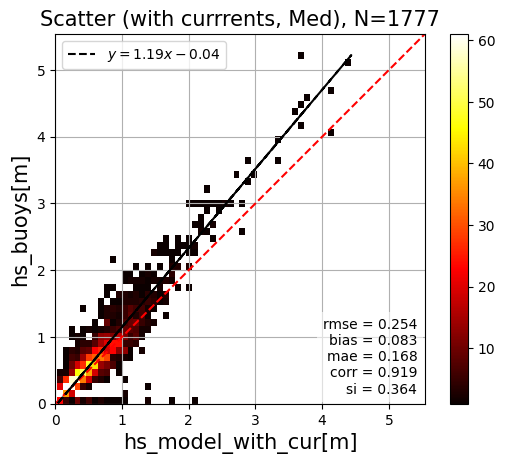

In [25]:
plot_scatter(df_all, var1='hs_model_with_cur', var2='hs_buoys', annotation_position='bottom-right',
   var1_units='m',
   var2_units='m',
   title=f'Scatter (with currrents, {Region_plots})',
   regression_line='effective-variance',
   qqplot=False,
   density=True)
   #output_file=f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//Scatter_plots//with_cur//scatter_plot_with_cur ({Region_saves}).png")

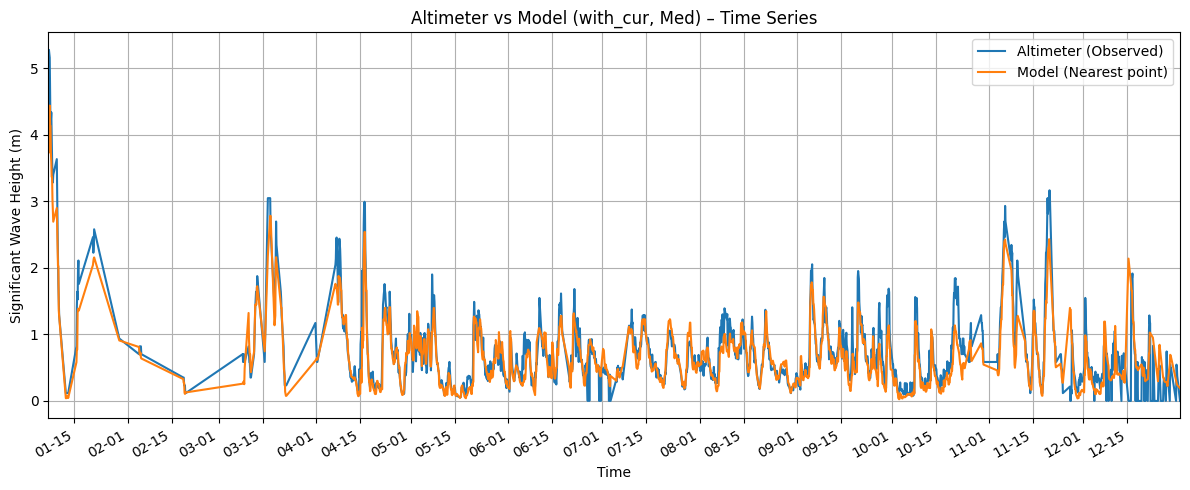

In [24]:
import matplotlib.pyplot as plt

# Ensure time is sorted
df_altim_plot = df_all.sort_values("time")
df_altim_plot["time"] = pd.to_datetime(df_altim_plot["time"])

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(df_altim_plot["time"], df_altim_plot["hs_buoys"], 
         label="Altimeter (Observed)", linewidth=1.5)

ax.plot(df_altim_plot["time"], df_altim_plot["hs_model_with_cur"], 
         label="Model (Nearest point)", linewidth="1.5")

#plt.scatter(df_altim_plot["time"], df_altim_plot["value"], 
 #        label="Altimeter (Observed)", marker='o', color='blue', s=10, alpha=0.7) 
#plt.scatter(df_altim_plot["time"], df_altim_plot["hs_model"], marker='o', color='red', s=10, alpha=0.7, label="Model (Nearest point)") 

xmin = df_altim_plot["time"].min()
xmax = df_altim_plot["time"].max()
ax.set_xlim(xmin, xmax)

# 2. Use AutoDateLocator to avoid too many labels
locator = mdates.AutoDateLocator(minticks=15, maxticks=20)
formatter = mdates.DateFormatter("%m-%d")

ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# Let matplotlib automatically choose tick spacing
fig.autofmt_xdate()

ax.set_xlabel("Time")
ax.set_ylabel("Significant Wave Height (m)")
ax.set_title(f"Altimeter vs Model (with_cur, {Region_plots}) – Time Series")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

#output_file=f"C://Users//kosta//OneDrive//Desktop//Διπλωματική//Results//Evaluation//Buoys evaluation//Time_series//with_cur//Altimeter_vs_model_hs (time series, with_cur - {Region_saves}).png"
#fig.savefig(output_file)